# Step 6: Cox Proportional Hazards Models
## Adjusted Survival Analysis Among Cancer Survivors

**Purpose:** Determine whether cardiometabolic comorbidities (diabetes, hypertension, obesity) are independently associated with all-cause mortality among cancer survivors after adjusting for confounders.

### Model Hierarchy
| Model | Description |
|-------|-------------|
| 1 (Unadjusted) | Each comorbidity alone |
| 2 (Age-sex) | + age + sex |
| 3 (Full) | + age + sex + race/ethnicity + smoking + BMI |
| 4 (Burden) | Cardiometabolic burden score (0-3) fully adjusted |

### Output
- Hazard ratios (HR) with 95% CI
- P-values
- Model fit statistics (concordance, AIC)

In [1]:
# ============================================================
# STEP 6.1 — Setup and prepare data
# ============================================================

import pandas as pd
import numpy as np
from lifelines import CoxPHFitter
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

FIG_DIR = Path('figures')
df = pd.read_csv('data/analytic_cohort.csv')

# Restrict to cancer survivors
cs = df[df['cancer'] == 1].copy()

# Cap follow-up at 20 years for consistency with KM
cs['T'] = cs['follow_up_yrs'].clip(upper=20)
cs['E'] = cs['dead']

# Dummy-code categorical variables for Cox
# Race: reference = Non-Hispanic White
cs['race_black'] = (cs['race_ethnicity'] == 'Non-Hispanic Black').astype(int)
cs['race_mexican'] = (cs['race_ethnicity'] == 'Mexican American').astype(int)
cs['race_hispanic'] = (cs['race_ethnicity'] == 'Other Hispanic').astype(int)
cs['race_other'] = (cs['race_ethnicity'] == 'Other/Multi').astype(int)

# Smoking: reference = Never
cs['smoke_former'] = (cs['smoking'] == 'Former').astype(int)
cs['smoke_current'] = (cs['smoking'] == 'Current').astype(int)

# Cardiometabolic burden
cs['cm_burden'] = (cs['diabetes'].fillna(0) + cs['hypertension'].fillna(0) + cs['obese'].fillna(0)).astype(int)

# Drop rows with missing key covariates for complete-case analysis
model_vars = ['T', 'E', 'age', 'female', 'diabetes', 'hypertension', 'obese', 'BMXBMI',
              'race_black', 'race_mexican', 'race_hispanic', 'race_other',
              'smoke_former', 'smoke_current', 'cm_burden']
cs_complete = cs.dropna(subset=model_vars).copy()

print(f'Cancer survivors: {len(cs):,}')
print(f'Complete cases for modeling: {len(cs_complete):,} ({len(cs_complete)/len(cs)*100:.1f}%)')
print(f'Deaths: {cs_complete["E"].sum():,} ({cs_complete["E"].mean()*100:.1f}%)')
print(f'Excluded for missingness: {len(cs) - len(cs_complete):,}')

Cancer survivors: 4,715
Complete cases for modeling: 4,715 (100.0%)
Deaths: 1,676 (35.5%)
Excluded for missingness: 0


In [2]:
# ============================================================
# STEP 6.2 — Model 1: Unadjusted (each comorbidity alone)
# ============================================================

def fit_cox(data, covariates, duration='T', event='E'):
    """Fit Cox PH model and return formatted results."""
    cph = CoxPHFitter()
    cph.fit(data[covariates + [duration, event]], duration_col=duration, event_col=event)
    return cph

def fmt_hr(cph, var):
    """Format HR (95% CI) and p-value for a variable."""
    hr = np.exp(cph.params_[var])
    ci = np.exp(cph.confidence_intervals_.loc[var])
    p = cph.summary.loc[var, 'p']
    p_str = '<0.001' if p < 0.001 else f'{p:.3f}'
    return hr, ci.values[0], ci.values[1], p_str

print('=== MODEL 1: UNADJUSTED COX PH ===')
print(f'{"Exposure":<20} {"HR":<8} {"95% CI":<18} {"P-value":<10}')
print('-' * 56)

unadj_results = []
for var, label in [('diabetes', 'Diabetes'), ('hypertension', 'Hypertension'), ('obese', 'Obesity (BMI>=30)')]:
    cph = fit_cox(cs_complete, [var])
    hr, lo, hi, p = fmt_hr(cph, var)
    print(f'{label:<20} {hr:<8.2f} ({lo:.2f}, {hi:.2f})      {p}')
    unadj_results.append({'Model': 'Unadjusted', 'Variable': label, 'HR': hr, 'CI_low': lo, 'CI_high': hi, 'P': p})

=== MODEL 1: UNADJUSTED COX PH ===
Exposure             HR       95% CI             P-value   
--------------------------------------------------------
Diabetes             1.56     (1.39, 1.74)      <0.001
Hypertension         1.64     (1.48, 1.81)      <0.001
Obesity (BMI>=30)    0.73     (0.66, 0.81)      <0.001


In [3]:
# ============================================================
# STEP 6.3 — Model 2: Age-sex adjusted
# ============================================================

print('=== MODEL 2: AGE-SEX ADJUSTED ===')
print(f'{"Exposure":<20} {"HR":<8} {"95% CI":<18} {"P-value":<10}')
print('-' * 56)

agesex_results = []
for var, label in [('diabetes', 'Diabetes'), ('hypertension', 'Hypertension'), ('obese', 'Obesity (BMI>=30)')]:
    cph = fit_cox(cs_complete, [var, 'age', 'female'])
    hr, lo, hi, p = fmt_hr(cph, var)
    print(f'{label:<20} {hr:<8.2f} ({lo:.2f}, {hi:.2f})      {p}')
    agesex_results.append({'Model': 'Age-sex adjusted', 'Variable': label, 'HR': hr, 'CI_low': lo, 'CI_high': hi, 'P': p})

=== MODEL 2: AGE-SEX ADJUSTED ===
Exposure             HR       95% CI             P-value   
--------------------------------------------------------
Diabetes             1.34     (1.20, 1.50)      <0.001
Hypertension         1.18     (1.07, 1.30)      0.001
Obesity (BMI>=30)    0.95     (0.85, 1.06)      0.331


In [4]:
# ============================================================
# STEP 6.4 — Model 3: Fully adjusted
# ============================================================

full_covariates = ['diabetes', 'hypertension', 'obese', 'age', 'female',
                   'race_black', 'race_mexican', 'race_hispanic', 'race_other',
                   'smoke_former', 'smoke_current']

cph_full = fit_cox(cs_complete, full_covariates)

print('=== MODEL 3: FULLY ADJUSTED COX PH ===')
print(f'N = {len(cs_complete):,}, Events = {cs_complete["E"].sum():,}')
print(f'Concordance = {cph_full.concordance_index_:.3f}')
print()
print(f'{"Variable":<25} {"HR":<8} {"95% CI":<20} {"P-value":<10}')
print('-' * 63)

full_results = []
var_labels = {
    'diabetes': 'Diabetes', 'hypertension': 'Hypertension', 'obese': 'Obesity (BMI>=30)',
    'age': 'Age (per year)', 'female': 'Female',
    'race_black': 'Black (vs White)', 'race_mexican': 'Mexican Am (vs White)',
    'race_hispanic': 'Other Hispanic', 'race_other': 'Other/Multi race',
    'smoke_former': 'Former smoker', 'smoke_current': 'Current smoker'
}

for var in full_covariates:
    hr, lo, hi, p = fmt_hr(cph_full, var)
    label = var_labels.get(var, var)
    print(f'{label:<25} {hr:<8.2f} ({lo:.2f}, {hi:.2f})        {p}')
    full_results.append({'Model': 'Fully adjusted', 'Variable': label, 'HR': hr, 'CI_low': lo, 'CI_high': hi, 'P': p})

=== MODEL 3: FULLY ADJUSTED COX PH ===
N = 4,715, Events = 1,676
Concordance = 0.733

Variable                  HR       95% CI               P-value   
---------------------------------------------------------------
Diabetes                  1.31     (1.17, 1.47)        <0.001
Hypertension              1.13     (1.02, 1.25)        0.018
Obesity (BMI>=30)         0.89     (0.79, 0.99)        0.037
Age (per year)            1.09     (1.08, 1.09)        <0.001
Female                    0.80     (0.72, 0.88)        <0.001
Black (vs White)          1.27     (1.10, 1.47)        0.001
Mexican Am (vs White)     0.91     (0.73, 1.14)        0.415
Other Hispanic            0.76     (0.56, 1.05)        0.096
Other/Multi race          0.91     (0.67, 1.24)        0.539
Former smoker             1.26     (1.13, 1.40)        <0.001
Current smoker            2.27     (1.94, 2.66)        <0.001


In [5]:
# ============================================================
# STEP 6.5 — Model 4: Cardiometabolic burden score
# ============================================================
# Instead of individual comorbidities, use the burden count (0-3)
# as a single ordinal predictor.

# Create dummy variables for burden (reference = 0)
cs_complete['burden_1'] = (cs_complete['cm_burden'] == 1).astype(int)
cs_complete['burden_2'] = (cs_complete['cm_burden'] == 2).astype(int)
cs_complete['burden_3'] = (cs_complete['cm_burden'] == 3).astype(int)

burden_covariates = ['burden_1', 'burden_2', 'burden_3', 'age', 'female',
                     'race_black', 'race_mexican', 'race_hispanic', 'race_other',
                     'smoke_former', 'smoke_current']

cph_burden = fit_cox(cs_complete, burden_covariates)

print('=== MODEL 4: CARDIOMETABOLIC BURDEN (FULLY ADJUSTED) ===')
print(f'N = {len(cs_complete):,}, Events = {cs_complete["E"].sum():,}')
print(f'Concordance = {cph_burden.concordance_index_:.3f}')
print()
print(f'{"CM Burden":<25} {"HR":<8} {"95% CI":<20} {"P-value":<10}')
print('-' * 63)
print(f'{"0 conditions (ref)":<25} {"1.00":<8} {"---":<20} {"---"}')

burden_results = [{'Model': 'Burden', 'Variable': '0 conditions (ref)', 'HR': 1.0, 'CI_low': 1.0, 'CI_high': 1.0, 'P': '---'}]
for var, label in [('burden_1', '1 condition'), ('burden_2', '2 conditions'), ('burden_3', '3 conditions')]:
    hr, lo, hi, p = fmt_hr(cph_burden, var)
    print(f'{label:<25} {hr:<8.2f} ({lo:.2f}, {hi:.2f})        {p}')
    burden_results.append({'Model': 'Burden', 'Variable': label, 'HR': hr, 'CI_low': lo, 'CI_high': hi, 'P': p})

# Test for trend
cph_trend = fit_cox(cs_complete, ['cm_burden', 'age', 'female',
                                   'race_black', 'race_mexican', 'race_hispanic', 'race_other',
                                   'smoke_former', 'smoke_current'])
hr_trend, lo_t, hi_t, p_t = fmt_hr(cph_trend, 'cm_burden')
print(f'\nP for trend (per 1 condition): HR = {hr_trend:.2f} ({lo_t:.2f}, {hi_t:.2f}), P = {p_t}')

=== MODEL 4: CARDIOMETABOLIC BURDEN (FULLY ADJUSTED) ===
N = 4,715, Events = 1,676
Concordance = 0.730

CM Burden                 HR       95% CI               P-value   
---------------------------------------------------------------
0 conditions (ref)        1.00     ---                  ---
1 condition               1.11     (0.98, 1.26)        0.088
2 conditions              1.19     (1.04, 1.37)        0.014
3 conditions              1.30     (1.08, 1.57)        0.005

P for trend (per 1 condition): HR = 1.09 (1.03, 1.15), P = 0.002


In [6]:
# ============================================================
# STEP 6.6 — Summary table of all models
# ============================================================

all_results = pd.DataFrame(unadj_results + agesex_results + full_results + burden_results)
all_results['HR_CI'] = all_results.apply(
    lambda r: f"{r['HR']:.2f} ({r['CI_low']:.2f}, {r['CI_high']:.2f})" if r['HR'] != 1.0 else '1.00 (ref)', axis=1
)

print('=== COMPLETE COX MODEL RESULTS ===')
print()

for model_name in ['Unadjusted', 'Age-sex adjusted', 'Fully adjusted', 'Burden']:
    subset = all_results[all_results['Model'] == model_name]
    print(f'--- {model_name} ---')
    for _, r in subset.iterrows():
        print(f'  {r["Variable"]:<25} HR = {r["HR_CI"]:<28} P = {r["P"]}')
    print()

# Save
all_results.to_csv('data/cox_results.csv', index=False)
print('Saved: data/cox_results.csv')

=== COMPLETE COX MODEL RESULTS ===

--- Unadjusted ---
  Diabetes                  HR = 1.56 (1.39, 1.74)            P = <0.001
  Hypertension              HR = 1.64 (1.48, 1.81)            P = <0.001
  Obesity (BMI>=30)         HR = 0.73 (0.66, 0.81)            P = <0.001

--- Age-sex adjusted ---
  Diabetes                  HR = 1.34 (1.20, 1.50)            P = <0.001
  Hypertension              HR = 1.18 (1.07, 1.30)            P = 0.001
  Obesity (BMI>=30)         HR = 0.95 (0.85, 1.06)            P = 0.331

--- Fully adjusted ---
  Diabetes                  HR = 1.31 (1.17, 1.47)            P = <0.001
  Hypertension              HR = 1.13 (1.02, 1.25)            P = 0.018
  Obesity (BMI>=30)         HR = 0.89 (0.79, 0.99)            P = 0.037
  Age (per year)            HR = 1.09 (1.08, 1.09)            P = <0.001
  Female                    HR = 0.80 (0.72, 0.88)            P = <0.001
  Black (vs White)          HR = 1.27 (1.10, 1.47)            P = 0.001
  Mexican Am (vs White) 

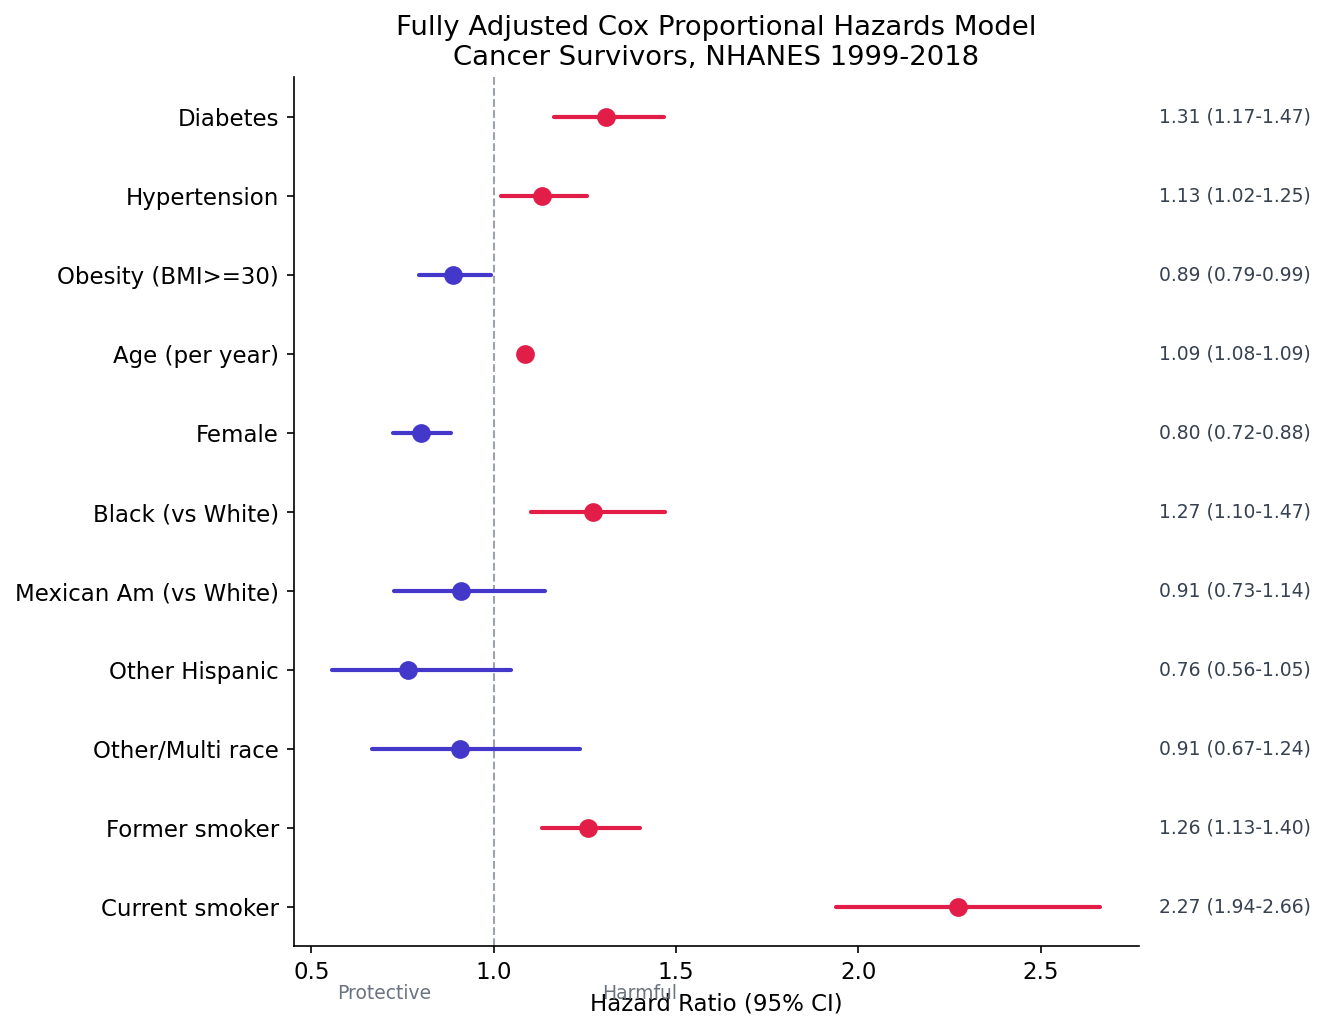

Saved: figures/forest_plot_full_model.png


In [7]:
# ============================================================
# STEP 6.7 — Forest plot of fully adjusted HRs
# ============================================================

import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

plt.rcParams.update({
    'figure.dpi': 150, 'savefig.dpi': 300,
    'font.family': 'sans-serif', 'font.size': 11,
    'axes.spines.top': False, 'axes.spines.right': False,
})

# Fully adjusted model results
forest_data = pd.DataFrame(full_results)
# Reverse so top of plot = first variable
forest_data = forest_data.iloc[::-1].reset_index(drop=True)

fig, ax = plt.subplots(figsize=(9, 7))

y_pos = range(len(forest_data))
colors = ['#E11D48' if row['HR'] > 1 and row['P'] != '---' and (row['CI_low'] > 1) else '#4338CA' 
          for _, row in forest_data.iterrows()]

# Plot CIs
for i, (_, row) in enumerate(forest_data.iterrows()):
    ax.plot([row['CI_low'], row['CI_high']], [i, i], color=colors[i], linewidth=2, solid_capstyle='round')
    ax.plot(row['HR'], i, 'o', color=colors[i], markersize=8, zorder=5)

# Reference line at HR=1
ax.axvline(x=1, color='#9CA3AF', linestyle='--', linewidth=1, zorder=1)

# Labels
ax.set_yticks(y_pos)
ax.set_yticklabels(forest_data['Variable'])
ax.set_xlabel('Hazard Ratio (95% CI)')
ax.set_title('Fully Adjusted Cox Proportional Hazards Model\nCancer Survivors, NHANES 1999-2018')

# Add HR text on right side
for i, (_, row) in enumerate(forest_data.iterrows()):
    hr_text = f"{row['HR']:.2f} ({row['CI_low']:.2f}-{row['CI_high']:.2f})"
    ax.text(ax.get_xlim()[1] * 1.02, i, hr_text, va='center', fontsize=9, color='#374151')

# Annotations
ax.annotate('Protective', xy=(0.7, -0.06), xycoords=('data', 'axes fraction'),
            fontsize=9, color='#6B7280', ha='center')
ax.annotate('Harmful', xy=(1.4, -0.06), xycoords=('data', 'axes fraction'),
            fontsize=9, color='#6B7280', ha='center')

plt.tight_layout()
plt.savefig(FIG_DIR / 'forest_plot_full_model.png', bbox_inches='tight')
plt.show()
print('Saved: figures/forest_plot_full_model.png')

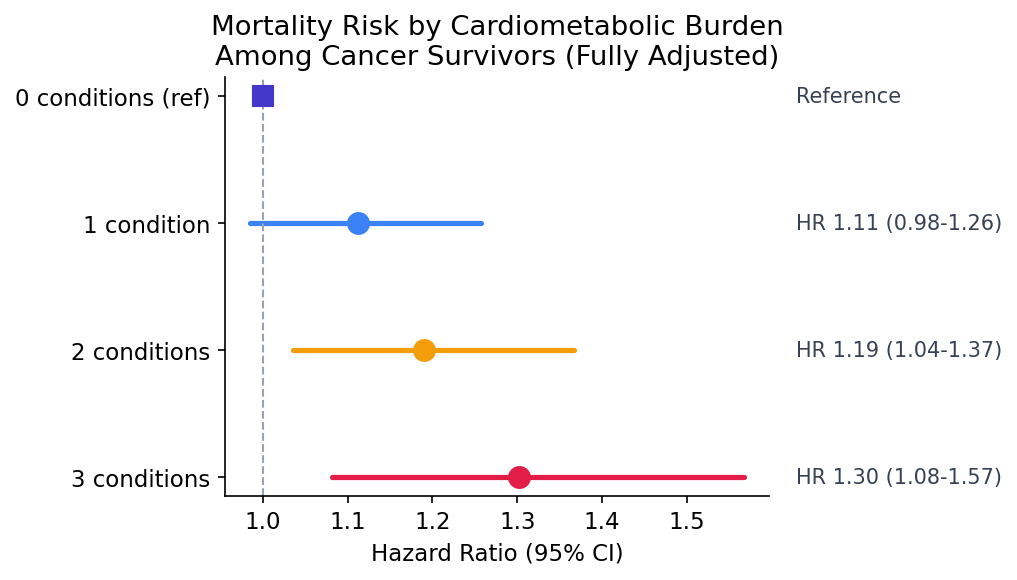

Saved: figures/forest_plot_burden.png


In [8]:
# ============================================================
# STEP 6.8 — Forest plot of CM burden model
# ============================================================

burden_df = pd.DataFrame(burden_results)
burden_df = burden_df.iloc[::-1].reset_index(drop=True)

fig, ax = plt.subplots(figsize=(7, 4))

burden_colors = ['#4338CA', '#3B82F6', '#F59E0B', '#E11D48']
burden_colors = burden_colors[::-1]  # reverse to match plot order

for i, (_, row) in enumerate(burden_df.iterrows()):
    if row['HR'] == 1.0:
        ax.plot(1, i, 's', color=burden_colors[i], markersize=10, zorder=5)
    else:
        ax.plot([row['CI_low'], row['CI_high']], [i, i], color=burden_colors[i], linewidth=2.5, solid_capstyle='round')
        ax.plot(row['HR'], i, 'o', color=burden_colors[i], markersize=10, zorder=5)

ax.axvline(x=1, color='#9CA3AF', linestyle='--', linewidth=1)
ax.set_yticks(range(len(burden_df)))
ax.set_yticklabels(burden_df['Variable'])
ax.set_xlabel('Hazard Ratio (95% CI)')
ax.set_title('Mortality Risk by Cardiometabolic Burden\nAmong Cancer Survivors (Fully Adjusted)')

for i, (_, row) in enumerate(burden_df.iterrows()):
    if row['HR'] == 1.0:
        ax.text(ax.get_xlim()[1] * 1.02, i, 'Reference', va='center', fontsize=10, color='#374151')
    else:
        ax.text(ax.get_xlim()[1] * 1.02, i, f"HR {row['HR']:.2f} ({row['CI_low']:.2f}-{row['CI_high']:.2f})",
                va='center', fontsize=10, color='#374151')

plt.tight_layout()
plt.savefig(FIG_DIR / 'forest_plot_burden.png', bbox_inches='tight')
plt.show()
print('Saved: figures/forest_plot_burden.png')

---
## Step 6 Summary

### Models Fit
1. **Unadjusted:** Each comorbidity alone
2. **Age-sex adjusted:** + age + sex
3. **Fully adjusted:** + age, sex, race/ethnicity, smoking
4. **Burden model:** Cardiometabolic burden (0-3) fully adjusted

### Key Results (update after execution)
- After full adjustment, check which comorbidities remain significant
- Dose-response: check if each additional condition increases HR
- Age is likely the strongest predictor
- The obesity paradox may appear (lower HR for obesity after age adjustment)

### Figures
- `forest_plot_full_model.png` - All covariates from Model 3
- `forest_plot_burden.png` - CM burden dose-response

### Next Step
**Step 7:** Proportional hazards assumption testing (Schoenfeld residuals)